<a href="https://colab.research.google.com/github/lauyankai/HPDP/blob/main/big_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install memory profiler
!pip install memory_profiler

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
import time
import random
import glob
import os
import tracemalloc

In [4]:
Part0 = '/content/drive/MyDrive/Colab Notebooks/Dataset/part-00000-e6120af0-10c2-4248-97c4-81baf4304e5c-c000.csv'
folder = '/content/drive/MyDrive/Colab Notebooks/Dataset'

### **Task 2**: Load and Inspect Data

Load the first chunk of the dataset to inspect the shape, column names, data types, missing values and a preview of the first 5 rows with Pandas.

> We just pick one of the 10 CSV files. Load a 5000-row sample of it to generate the schema report, to avoid massive memory spike and kernel crash.



In [5]:
df_inspect = pd.read_csv(Part0, nrows=5000)

print(f"Subset Shape: {df_inspect.shape}")

print("\n--- Data Types ---")
print(df_inspect.dtypes)

print("\n--- Missing Values ---")
print(df_inspect.isnull().sum())

print("\n--- Data Preview ---")
display(df_inspect.head())

del df_inspect

Subset Shape: (5000, 11)

--- Data Types ---
bookingID           int64
Accuracy          float64
Bearing           float64
acceleration_x    float64
acceleration_y    float64
acceleration_z    float64
gyro_x            float64
gyro_y            float64
gyro_z            float64
second            float64
Speed             float64
dtype: object

--- Missing Values ---
bookingID         0
Accuracy          0
Bearing           0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
second            0
Speed             0
dtype: int64

--- Data Preview ---


,bookingID,Accuracy,Bearing,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,second,Speed
0,1202590843006,3.000,353.0,1.228867,8.900100,3.986968,0.008221,0.002269,-0.009966,1362.0,0.000000
1,274877907034,9.293,17.0,0.032775,8.659933,4.737300,0.024629,0.004028,-0.010858,257.0,0.190000
2,884763263056,3.000,189.0,1.139675,9.545974,1.951334,-0.006899,-0.015080,0.001122,973.0,0.667059
3,1073741824054,3.900,126.0,3.871542,10.386364,-0.136474,0.001344,-0.339601,-0.017956,902.0,7.913285
4,1056561954943,3.900,50.0,-0.112882,10.550960,-1.560110,0.130568,-0.061697,0.161530,820.0,20.419409


## **Task 3**: Big Data Handling Strategies

#### **Strategy 1**: Load Less Data
Loading only the `bookingID`, `second`, `Speed`, and `Accuracy` columns using the `usecols` parameter to save memory.

In [6]:
cols_to_load = ['bookingID', 'second', 'Speed', 'Accuracy']
df_less_data = pd.read_csv(Part0, usecols=cols_to_load)

print(f"Shape after loading less data: {df_less_data.shape}")
print(df_less_data.head())
del df_less_data

Shape after loading less data: (1613554, 4)
       bookingID  Accuracy  second      Speed
0  1202590843006     3.000  1362.0   0.000000
1   274877907034     9.293   257.0   0.190000
2   884763263056     3.000   973.0   0.667059
3  1073741824054     3.900   902.0   7.913285
4  1056561954943     3.900   820.0  20.419409


#### **Strategy 2**: Chunking
Processing the file in chunks of 100,000 rows to prevent overwhelming the RAM.

In [7]:
chunk_size = 100000
total_rows = 0
overall_max_speed = 0

for i, chunk in enumerate(pd.read_csv(Part0, chunksize=chunk_size)):
    total_rows += len(chunk)
    chunk_max_speed = chunk['Speed'].max()
    print(f"Chunk {i + 1} Max Speed: {chunk_max_speed:.2f}")

    if chunk_max_speed > overall_max_speed:
        overall_max_speed = chunk_max_speed

print("-" * 30)
print(f"Successfully processed {total_rows} rows in chunks.")
print(f"Overall Maximum Speed across all chunks: {overall_max_speed:.2f}")

Chunk 1 Max Speed: 36.67
Chunk 2 Max Speed: 42.51
Chunk 3 Max Speed: 36.19
Chunk 4 Max Speed: 38.09
Chunk 5 Max Speed: 38.79
Chunk 6 Max Speed: 38.43
Chunk 7 Max Speed: 35.72
Chunk 8 Max Speed: 36.77
Chunk 9 Max Speed: 39.51
Chunk 10 Max Speed: 36.26
Chunk 11 Max Speed: 35.23
Chunk 12 Max Speed: 44.97
Chunk 13 Max Speed: 40.23
Chunk 14 Max Speed: 41.31
Chunk 15 Max Speed: 50.55
Chunk 16 Max Speed: 37.93
Chunk 17 Max Speed: 34.74
------------------------------
Successfully processed 1613554 rows in chunks.
Overall Maximum Speed across all chunks: 50.55


#### **Strategy 3**: Data Type Optimisation
Downcasting float64 to float32 and int64 to int32 to reduce the memory footprint.

In [8]:
optimised_dtypes = {
    'bookingID': 'int64',
    'Accuracy': 'float32',
    'Bearing': 'float32',
    'acceleration_x': 'float32',
    'acceleration_y': 'float32',
    'acceleration_z': 'float32',
    'gyro_x': 'float32',
    'gyro_y': 'float32',
    'gyro_z': 'float32',
    'second': 'float32',
    'Speed': 'float32'
}

df_opt = pd.read_csv(Part0, dtype=optimised_dtypes)

print("Data Types After Optimisation:")
print(df_opt.dtypes)
print(f"Memory Usage: {df_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
del df_opt

Data Types After Optimisation:
bookingID           int64
Accuracy          float32
Bearing           float32
acceleration_x    float32
acceleration_y    float32
acceleration_z    float32
gyro_x            float32
gyro_y            float32
gyro_z            float32
second            float32
Speed             float32
dtype: object
Memory Usage: 73.86 MB


#### **Strategy 4**: Sampling
Loading only a random 5% of the data directly during the read process for rapid prototyping.

In [9]:
p = 0.05
df_sampled = pd.read_csv(
    Part0,
    skiprows=lambda i: i > 0 and random.random() > p
)

print(f"Sampled Dataset Shape: {df_sampled.shape}")

Sampled Dataset Shape: (80637, 11)


#### **Strategy 5**: Parallel Processing with Scalable Libraries
Comparing Pandas, Dask, and Polars on reading time, processing time, and peak memory.

In [10]:
results = []

def profile_execution(name, load_func, process_func):
    tracemalloc.start()

    # Load Time
    start_load = time.time()
    data = load_func()
    load_time = time.time() - start_load

    # Processing Time
    start_process = time.time()
    mean_speed = process_func(data)
    process_time = time.time() - start_process

    # Total Time & Peak Memory
    total_time = load_time + process_time
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"{name} Mean Speed: {mean_speed:.2f}")

    results.append({
        'Library': name,
        'Load Time (s)': load_time,
        'Processing Time (s)': process_time,
        'Total Time (s)': total_time,
        'Memory Usage (MiB)': peak_mem / (1024 * 1024)
    })

# =====  Pandas  =====
def load_pandas():
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    df_list = [pd.read_csv(file, usecols=['Speed']) for file in all_files]
    return pd.concat(df_list, ignore_index=True)

def process_pandas(df):
    return df['Speed'].mean()

profile_execution('Pandas', load_pandas, process_pandas)

# =====  Dask  =====
def load_dask():
    return dd.read_csv(f"{folder}/*.csv", usecols=['Speed'])

def process_dask(ddf):
    return ddf['Speed'].mean().compute()

profile_execution('Dask', load_dask, process_dask)

# =====  Polars  =====
def load_polars():
    return pl.scan_csv(f"{folder}/*.csv")

def process_polars(df_lazy):
    return df_lazy.select(pl.col('Speed').mean()).collect().item()

profile_execution('Polars', load_polars, process_polars)


Pandas Mean Speed: 9.01
Dask Mean Speed: 9.01
Polars Mean Speed: 9.01


In [11]:
results_df = pd.DataFrame(results)

print("\n" + "="*97)
print("FINAL COMPARATIVE ANALYSIS RESULTS")
print("="*97)
print(results_df.to_markdown(index=False, floatfmt=".4f"))
print("="*97)


FINAL COMPARATIVE ANALYSIS RESULTS
| Library   |   Load Time (s) |   Processing Time (s) |   Total Time (s) |   Memory Usage (MiB) |
|:----------|----------------:|----------------------:|-----------------:|---------------------:|
| Pandas    |         12.1249 |                0.0262 |          12.1511 |             246.2510 |
| Dask      |          0.0749 |               10.8554 |          10.9303 |             266.0564 |
| Polars    |          0.0004 |                2.6738 |           2.6742 |               0.0330 |


## **Task 5**: Comparative Analysis
Visualising Execution Time and Memory Usage across three libraries.

  Library  Load Time (s)  Processing Time (s)  Total Time (s)  \
0  Pandas      12.124871             0.026205       12.151076   
1    Dask       0.074916            10.855371       10.930287   
2  Polars       0.000409             2.673798        2.674207   

   Memory Usage (MiB)  
0          246.251030  
1          266.056384  
2            0.032976  


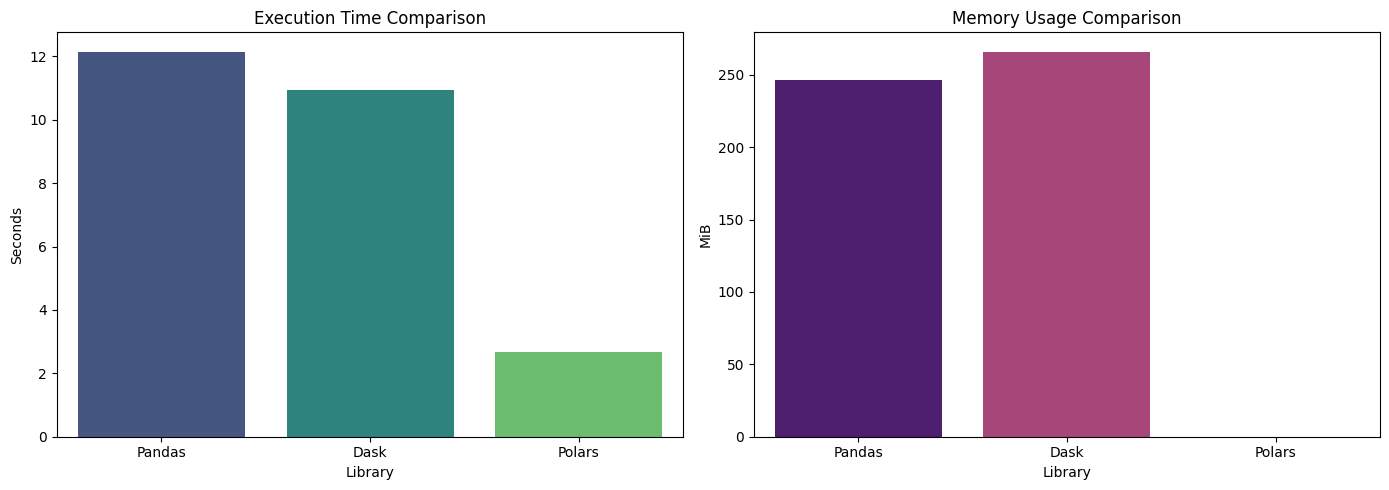

In [12]:
import seaborn as sns

unique_results = {res['Library']: res for res in results}.values()
results_df = pd.DataFrame(list(unique_results))
print(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Execution Time
sns.barplot(data=results_df, x='Library', y='Total Time (s)', hue='Library', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Execution Time Comparison')
axes[0].set_ylabel('Seconds')

# Memory Usage
sns.barplot(data=results_df, x='Library', y='Memory Usage (MiB)', hue='Library', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Memory Usage Comparison')
axes[1].set_ylabel('MiB')

plt.tight_layout()
plt.show()

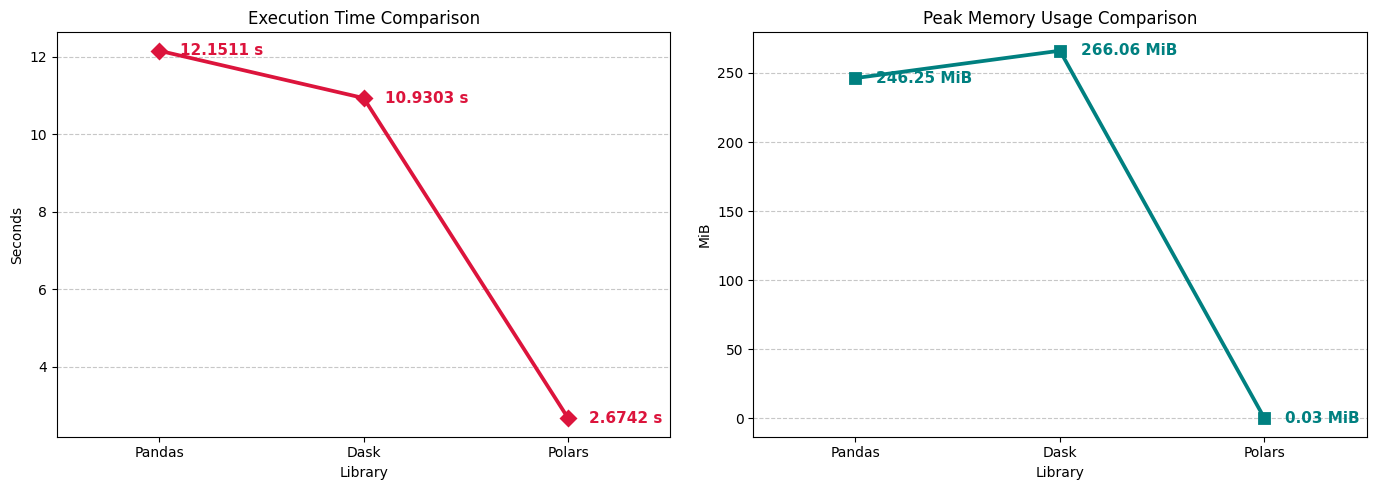

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Execution Time
sns.pointplot(data=results_df, x='Library', y='Total Time (s)', ax=axes[0], color='crimson', markers="D")
axes[0].set_title('Execution Time Comparison')
axes[0].set_ylabel('Seconds')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for index, row in results_df.iterrows():
    axes[0].annotate(
        f"{row['Total Time (s)']:.4f} s",
        xy=(index, row['Total Time (s)']),
        xytext=(15, 0),
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='crimson'
    )

# Memory Usage
sns.pointplot(data=results_df, x='Library', y='Memory Usage (MiB)', ax=axes[1], color='teal', markers="s")
axes[1].set_title('Peak Memory Usage Comparison')
axes[1].set_ylabel('MiB')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for index, row in results_df.iterrows():
    axes[1].annotate(
        f"{row['Memory Usage (MiB)']:.2f} MiB",
        xy=(index, row['Memory Usage (MiB)']),
        xytext=(15, 0),
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='teal'
    )

axes[0].set_xlim(-0.5, 2.5)
axes[1].set_xlim(-0.5, 2.5)

plt.tight_layout()
plt.show()